<a href="https://colab.research.google.com/github/MishaE-e/ml_fmi/blob/main/6_%D1%87%D0%B0%D1%81%D1%82%D1%8C_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Набор данных: https://archive.ics.uci.edu/dataset/837/product+classification+and+clustering

In [ ]:
import pandas as pd
import numpy as np

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.utils.data as data_utils

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

2. Загрузка данных


In [ ]:
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Correct Group", "Anomaly"]

In [ ]:
df = pd.read_csv('pricerunner_aggregate.csv')

In [ ]:
df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product ID       35311 non-null  int64 
 1   Product Title    35311 non-null  object
 2    Merchant ID     35311 non-null  int64 
 3    Cluster ID      35311 non-null  int64 
 4    Cluster Label   35311 non-null  object
 5    Category ID     35311 non-null  int64 
 6    Category Label  35311 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.9+ MB


3. Проверка на пропуски

In [ ]:
print(f"Пропуски в данных:\n{df.isnull().sum()}")
df = df.dropna(subset=['Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label'])
print(f"После удаления пропусков: {df.shape}")

Пропуски в данных:
Product ID         0
Product Title      0
 Merchant ID       0
 Cluster ID        0
 Cluster Label     0
 Category ID       0
 Category Label    0
dtype: int64
После удаления пропусков: (35311, 7)


4. Предобработка

In [ ]:
print("Анализ категорий и кластеров:")
print(f"Уникальных Cluster ID: {df[' Cluster ID'].nunique()}")
print(f"Уникальных Category ID: {df[' Category ID'].nunique()}")
print(f"Уникальных Merchant ID: {df[' Merchant ID'].nunique()}")

Анализ категорий и кластеров:
Уникальных Cluster ID: 13233
Уникальных Category ID: 10
Уникальных Merchant ID: 306


In [ ]:
numeric_cols = ['Product ID', ' Merchant ID', ' Cluster ID', ' Category ID']
categorical_cols = ['Product Title', ' Cluster Label', ' Category Label']

In [ ]:
all_cols = numeric_cols + categorical_cols
df_processed = df[all_cols].copy()

перекодировка

In [ ]:
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    le_dict[col] = le

маштобирование

In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_processed),
    columns=df_processed.columns
)

5. Обучение

In [ ]:
X = df_scaled.values

In [ ]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=RANDOM_SEED)

In [ ]:
X_train_tensor = torch.from_numpy(X_train).double()
X_test_tensor = torch.from_numpy(X_test).double()

In [ ]:
train_loader = data_utils.DataLoader(X_train_tensor, batch_size=32, shuffle=True)
test_loader = data_utils.DataLoader(X_test_tensor, batch_size=1, shuffle=False)

In [ ]:
input_dim = X_train.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.Tanh(),
            nn.Linear(input_dim // 2, input_dim // 4),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(input_dim // 4, input_dim // 2),
            nn.Tanh(),
            nn.Linear(input_dim // 2, input_dim),
            nn.ReLU()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder(input_dim).double()

In [ ]:
num_epochs = 50
learning_rate = 1e-3

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

history = {'train_loss': []}

print("Начало обучения")
for epoch in range(num_epochs):
    epoch_losses = []
    for data in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    mean_loss = np.mean(epoch_losses)
    history['train_loss'].append(mean_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {mean_loss:.6f}')

Начало обучения
Epoch [10/50], Loss: 0.821127
Epoch [20/50], Loss: 0.809570
Epoch [30/50], Loss: 0.738459
Epoch [40/50], Loss: 0.736206
Epoch [50/50], Loss: 0.735407


6. Оценка

In [ ]:
model.eval()
reconstruction_errors = []
with torch.no_grad():
    for data in test_loader:
        output = model(data)
        loss = criterion(output, data)
        reconstruction_errors.append(loss.item())

df с ошибками

In [ ]:
test_df = pd.DataFrame({'reconstruction_error': reconstruction_errors, 'is_anomaly': 0})

In [ ]:
test_df

,reconstruction_error,is_anomaly
0,0.628105,0
1,1.502272,0
2,2.221445,0
3,0.473699,0
4,1.221768,0
...,...,...
7058,0.552058,0
7059,0.865499,0
7060,0.905496,0
7061,1.566294,0


In [ ]:
test_df['reconstruction_error'].describe()

,reconstruction_error
count,7063.000000
mean,0.730559
std,0.518405
min,0.018919
25%,0.376950
50%,0.587001
75%,0.960016
max,2.324787


выбор порога

In [ ]:
threshold = np.percentile(test_df['reconstruction_error'], 95)
print(f"\nВыбранный порог: {threshold:.4f}") #95 процентиль

test_df['is_anomaly'] = (test_df['reconstruction_error'] > threshold).astype(int)


Выбранный порог: 1.7316


7. Визуализация

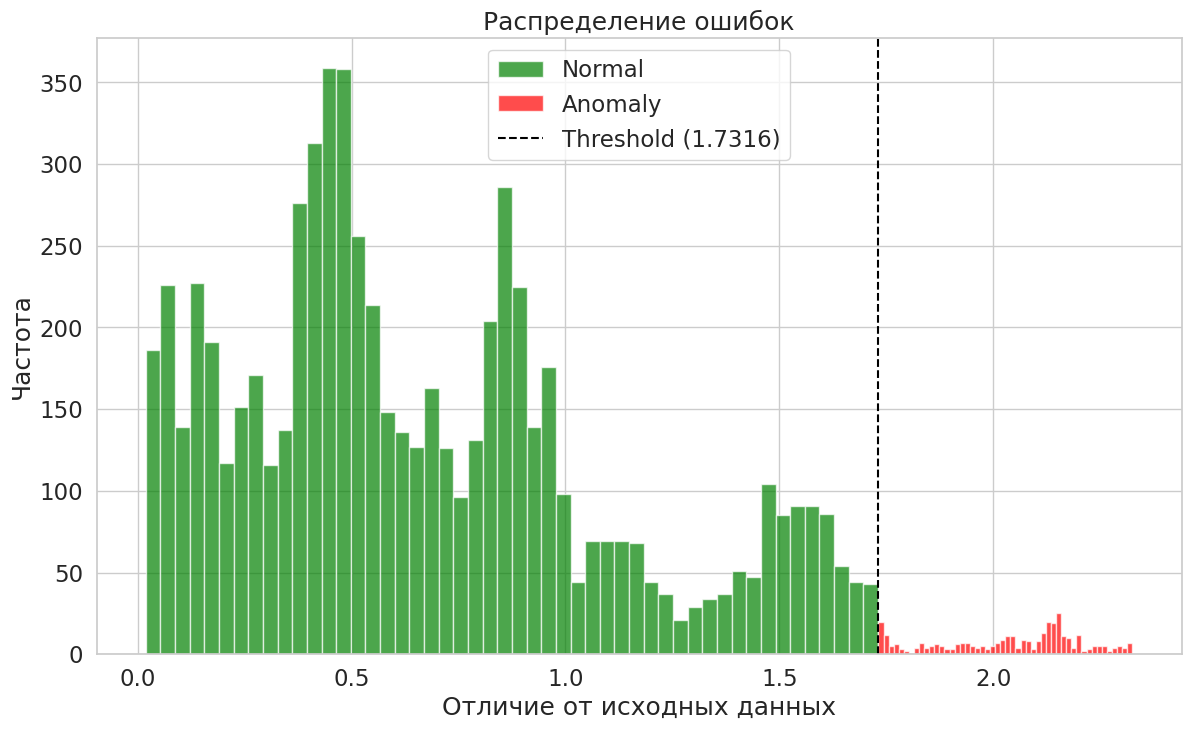

In [ ]:
plt.hist(test_df[test_df['is_anomaly'] == 0]['reconstruction_error'], bins=50, alpha=0.7, label='Normal', color='green')
plt.hist(test_df[test_df['is_anomaly'] == 1]['reconstruction_error'], bins=50, alpha=0.7, label='Anomaly', color='red')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.xlabel('Отличие от исходных данных')
plt.ylabel('Частота')
plt.title('Распределение ошибок')
plt.legend()

добавление в исходный df колонку с ошибкой

In [ ]:
X_train_idx, X_test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=RANDOM_SEED)

test_indices = X_test_idx
reconstruction_errors_full = np.zeros(len(X))
reconstruction_errors_full[test_indices] = reconstruction_errors

df['reconstruction_error'] = reconstruction_errors_full

In [ ]:
df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label,reconstruction_error
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0.000000
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0.000000
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0.000000
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0.000000
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,2.164456
...,...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges,0.000000
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges,0.000000
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges,0.000000
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges,0.421080
